In [3]:

import pandas as pd
df=pd.read_csv("income.csv")
df

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_level
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0
...,...,...,...,...,...,...,...
48837,39,215419,13,0,0,36,0
48838,64,321403,9,0,0,40,0
48839,38,374983,13,0,0,50,0
48840,44,83891,13,5455,0,40,0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define features (X) and target (y)
X = df.drop('income_level', axis=1)
y = df['income_level']

# Identify categorical columns for encoding
# We'll assume 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'age', 'fnlwgt' are numerical.
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data preprocessing complete. Shapes of training and testing sets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Data preprocessing complete. Shapes of training and testing sets:
X_train: (34189, 6), y_train: (34189,)
X_test: (14653, 6), y_test: (14653,)


In [13]:
import numpy as np

n_estimators_range = np.arange(1, 101, 5) # Test n_estimators from 1 to 100 with steps of 5
scores = []

best_score = 0
best_n_estimators = 0

for n in n_estimators_range:
    adaboost_clf = AdaBoostClassifier(n_estimators=n, random_state=42)
    adaboost_clf.fit(X_train, y_train)
    y_pred = adaboost_clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    scores.append(accuracy)

    if accuracy > best_score:
        best_score = accuracy
        best_n_estimators = n

print(f"Best accuracy achieved: {best_score:.4f}")
print(f"Optimal n_estimators: {best_n_estimators}")

Best accuracy achieved: 0.8308
Optimal n_estimators: 96


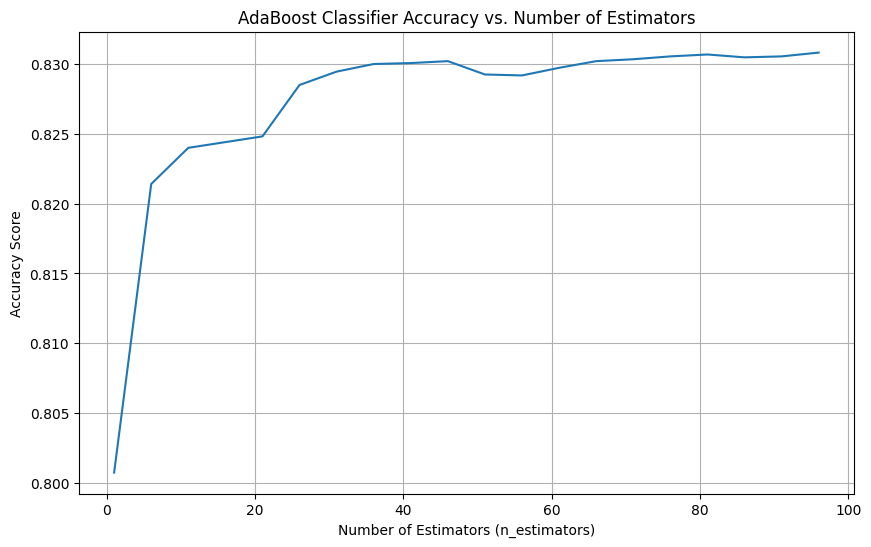

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x=n_estimators_range, y=scores)
plt.title('AdaBoost Classifier Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()